# DenseNet-121 - NIH ChestX-ray14
**Multi-Label Thoracic Disease Classification | Advanced Model**

In [1]:
import os, glob, time, copy, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.cuda.amp as amp
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


## 1. Data Loading

In [2]:
# ── Kaggle dataset path ───────────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'  

all_image_paths = {}
for subfolder in sorted(glob.glob(os.path.join(DATA_DIR, "images_0*"))):
    img_folder = os.path.join(subfolder, "images")
    if os.path.exists(img_folder):
        for f in os.listdir(img_folder):
            all_image_paths[f] = os.path.join(img_folder, f)

df = pd.read_csv(os.path.join(DATA_DIR, "Data_Entry_2017.csv"))
df['labels_list'] = df['Finding Labels'].str.split('|')

mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(df['labels_list'])
label_cols   = mlb.classes_.tolist()
DISEASE_COLS = [c for c in label_cols if c != 'No Finding']
NUM_CLASSES  = len(DISEASE_COLS)

label_df = pd.DataFrame(label_matrix, columns=label_cols)
df = pd.concat([df.reset_index(drop=True), label_df], axis=1)

with open(os.path.join(DATA_DIR, "train_val_list.txt")) as f:
    train_val_files = set(f.read().splitlines())
with open(os.path.join(DATA_DIR, "test_list.txt")) as f:
    test_files = set(f.read().splitlines())

df_trainval = df[df['Image Index'].isin(train_val_files)].reset_index(drop=True)
df_test     = df[df['Image Index'].isin(test_files)].reset_index(drop=True)

train_patients, val_patients = train_test_split(
    df_trainval['Patient ID'].unique(), test_size=0.1, random_state=SEED)

df_train = df_trainval[df_trainval['Patient ID'].isin(train_patients)].reset_index(drop=True)
df_val   = df_trainval[df_trainval['Patient ID'].isin(val_patients)].reset_index(drop=True)

assert len(set(df_train['Patient ID']) & set(df_val['Patient ID']))  == 0
assert len(set(df_train['Patient ID']) & set(df_test['Patient ID'])) == 0

pos_counts        = df_train[DISEASE_COLS].sum()
neg_counts        = len(df_train) - pos_counts
pos_weight_values = (neg_counts / pos_counts).values.astype(np.float32)
pos_weight_tensor = torch.tensor(pos_weight_values).to(DEVICE)

print(f"Images  : {len(all_image_paths):,}")
print(f"Train   : {len(df_train):,}  |  Val : {len(df_val):,}  |  Test : {len(df_test):,}")

Images  : 112,120
Train   : 77,988  |  Val : 8,536  |  Test : 25,596


## 2. Dataset & DataLoaders

In [3]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_path_dict, label_cols, transform=None):
        self.df              = dataframe.reset_index(drop=True)
        self.image_path_dict = image_path_dict
        self.label_cols      = label_cols
        self.transform       = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(self.image_path_dict[row['Image Index']]).convert('RGB')
        if self.transform: image = self.transform(image)
        labels = torch.tensor(row[self.label_cols].values.astype(np.float32))
        return image, labels


train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

BATCH_SIZE  = 128  # 64 per GPU across 2× T4
NUM_WORKERS = 2    # Kaggle cap

loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=True,
                     persistent_workers=True, prefetch_factor=2)

train_dataset = ChestXrayDataset(df_train, all_image_paths, DISEASE_COLS, train_transform)
val_dataset   = ChestXrayDataset(df_val,   all_image_paths, DISEASE_COLS, val_test_transform)
test_dataset  = ChestXrayDataset(df_test,  all_image_paths, DISEASE_COLS, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print(f"Train batches : {len(train_loader)} | Val : {len(val_loader)} | Test : {len(test_loader)}")

Train batches : 610 | Val : 67 | Test : 200


## 3. Model — DenseNet-121
Every layer connects to all subsequent layers, enabling better gradient flow and feature reuse — the gold standard for X-ray classification (CheXNet, 2017).

In [4]:
def build_densenet121(num_classes=14):
    model = models.densenet121(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.classifier.in_features, num_classes)
    )
    return model


model_dense = build_densenet121(NUM_CLASSES).to(DEVICE)

# Use both T4 GPUs if available
num_gpus = torch.cuda.device_count()
if num_gpus > 1:
    print(f"Using {num_gpus} GPUs with DataParallel")
    model_dense = nn.DataParallel(model_dense)

total_p     = sum(p.numel() for p in model_dense.parameters())
trainable_p = sum(p.numel() for p in model_dense.parameters() if p.requires_grad)
print(f"Total params    : {total_p:,}")
print(f"Trainable now   : {trainable_p:,}  (head only — backbone frozen)")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 166MB/s] 


Using 2 GPUs with DataParallel
Total params    : 6,968,206
Trainable now   : 14,350  (head only — backbone frozen)


## 4. Architecture Visualisation

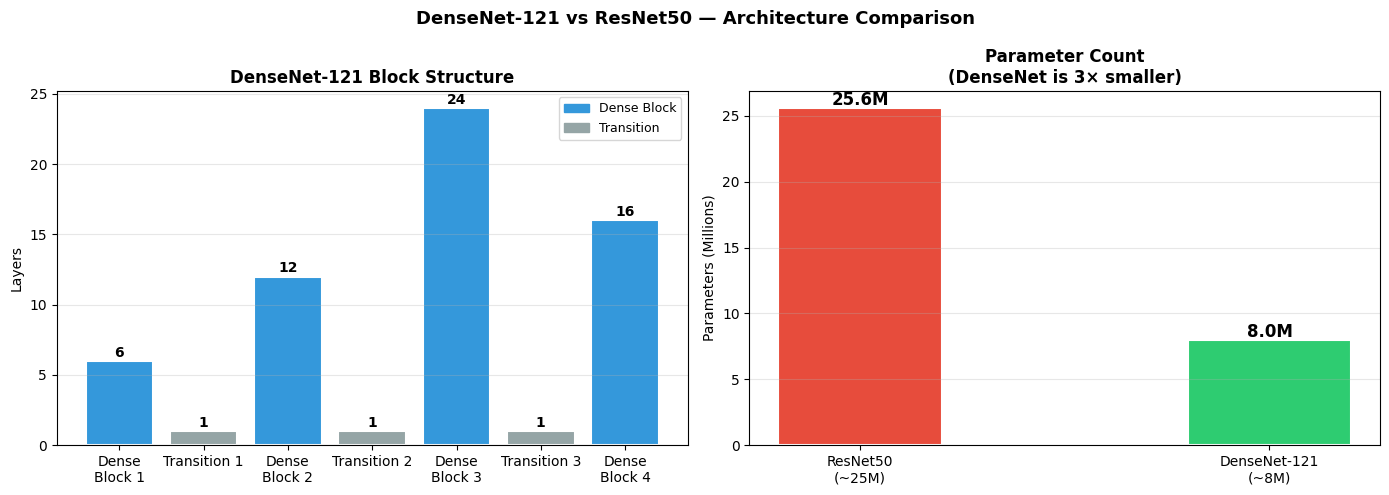

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DenseNet-121 vs ResNet50 — Architecture Comparison', fontsize=13, fontweight='bold')

ax = axes[0]
blocks     = ['Dense\nBlock 1','Transition 1','Dense\nBlock 2','Transition 2',
               'Dense\nBlock 3','Transition 3','Dense\nBlock 4']
num_layers = [6, 1, 12, 1, 24, 1, 16]
colors_blk = ['#3498db','#95a5a6','#3498db','#95a5a6','#3498db','#95a5a6','#3498db']
bars = ax.bar(blocks, num_layers, color=colors_blk, edgecolor='white', linewidth=1.5)
for bar, n in zip(bars, num_layers):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3, str(n), ha='center', fontweight='bold')
ax.set_title('DenseNet-121 Block Structure', fontweight='bold'); ax.set_ylabel('Layers')
ax.legend(handles=[mpatches.Patch(color='#3498db', label='Dense Block'),
                   mpatches.Patch(color='#95a5a6', label='Transition')], fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.bar(['ResNet50\n(~25M)','DenseNet-121\n(~8M)'], [25.6, 8.0],
        color=['#e74c3c','#2ecc71'], edgecolor='white', linewidth=1.5, width=0.4)
for bar, p in zip(ax2.patches, [25.6, 8.0]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{p}M', ha='center', fontweight='bold', fontsize=12)
ax2.set_title('Parameter Count\n(DenseNet is 3× smaller)', fontweight='bold')
ax2.set_ylabel('Parameters (Millions)'); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Training Utilities

In [6]:
def unnormalize(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (t * std + mean).clamp(0, 1)


def compute_auc(model, loader, device, disease_cols):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in loader:
            probs = torch.sigmoid(model(images.to(device)))
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    all_labels = np.vstack(all_labels)
    all_probs  = np.vstack(all_probs)
    per_class  = {}
    for i, d in enumerate(disease_cols):
        if all_labels[:, i].sum() > 0:
            per_class[d] = roc_auc_score(all_labels[:, i], all_probs[:, i])
        else:
            per_class[d] = float('nan')
    return np.nanmean(list(per_class.values())), per_class, all_labels, all_probs


def validate_loss(model, loader, criterion, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for images, labels in loader:
            total += criterion(model(images.to(device)), labels.to(device)).item()
    return total / len(loader)


print("Utilities defined ✓")

Utilities defined ✓


## 6. Phase 1 — Train Head Only (Backbone Frozen)

In [7]:
criterion    = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_d1 = optim.Adam(filter(lambda p: p.requires_grad, model_dense.parameters()), lr=1e-3)
scheduler_d1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_d1, mode='min', patience=2, factor=0.5)
scaler       = amp.GradScaler()

EPOCHS_P1 = 3
history   = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'lr': []}
best_auc  = 0.0
best_wts  = copy.deepcopy(model_dense.state_dict())

print(f"{'='*55}")
print("PHASE 1 — Head only (backbone frozen)")
print(f"{'='*55}")

for epoch in range(1, EPOCHS_P1 + 1):
    t0 = time.time()
    model_dense.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"E{epoch}/{EPOCHS_P1} [Phase 1]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_d1.zero_grad()
        with amp.autocast():
            loss = criterion(model_dense(images), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer_d1); scaler.update()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / (pbar.n + 1):.4f}")

    train_loss = running_loss / len(train_loader)
    val_loss   = validate_loss(model_dense, val_loader, criterion, DEVICE)
    val_auc, _, _, _ = compute_auc(model_dense, val_loader, DEVICE, DISEASE_COLS)
    scheduler_d1.step(val_loss)
    lr = optimizer_d1.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['lr'].append(lr)

    print(f"Epoch {epoch}/{EPOCHS_P1} | Loss {train_loss:.4f}/{val_loss:.4f} | AUC {val_auc:.4f} | LR {lr:.2e} | {(time.time()-t0)/60:.1f}m")
    if val_auc > best_auc:
        best_auc = val_auc
        best_wts = copy.deepcopy(model_dense.state_dict())
        torch.save(best_wts, 'densenet121_best.pth')
        print(f"  ✓ New best AUC {best_auc:.4f} — saved")

PHASE 1 — Head only (backbone frozen)


E1/3 [Phase 1]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 1/3 | Loss 1.3101/1.2351 | AUC 0.7097 | LR 1.00e-03 | 29.3m
  ✓ New best AUC 0.7097 — saved


E2/3 [Phase 1]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 2/3 | Loss 1.2486/1.2157 | AUC 0.7133 | LR 1.00e-03 | 28.8m
  ✓ New best AUC 0.7133 — saved


E3/3 [Phase 1]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 3/3 | Loss 1.2431/1.2082 | AUC 0.7147 | LR 1.00e-03 | 27.7m
  ✓ New best AUC 0.7147 — saved


## 7. Phase 2 — Full Fine-Tuning
Cosine Annealing with Warm Restarts + AMP throughout.

In [8]:
for param in model_dense.parameters():
    param.requires_grad = True

optimizer_d2 = optim.Adam(model_dense.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler_d2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_d2, T_0=3, T_mult=2, eta_min=1e-6)
scaler       = amp.GradScaler()

EPOCHS_P2 = 7

print(f"{'='*55}")
print("PHASE 2 — Full fine-tuning (Cosine Annealing + AMP)")
print(f"  Trainable params: {sum(p.numel() for p in model_dense.parameters() if p.requires_grad):,}")
print(f"{'='*55}")

for epoch in range(1, EPOCHS_P2 + 1):
    t0 = time.time()
    model_dense.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"E{EPOCHS_P1+epoch}/{EPOCHS_P1+EPOCHS_P2} [Phase 2]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer_d2.zero_grad()
        with amp.autocast():
            loss = criterion(model_dense(images), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer_d2); scaler.update()
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / (pbar.n + 1):.4f}")

    train_loss = running_loss / len(train_loader)
    val_loss   = validate_loss(model_dense, val_loader, criterion, DEVICE)
    val_auc, _, _, _ = compute_auc(model_dense, val_loader, DEVICE, DISEASE_COLS)
    scheduler_d2.step()
    lr = optimizer_d2.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['lr'].append(lr)

    print(f"Epoch {EPOCHS_P1+epoch}/{EPOCHS_P1+EPOCHS_P2} | Loss {train_loss:.4f}/{val_loss:.4f} | AUC {val_auc:.4f} | LR {lr:.2e} | {(time.time()-t0)/60:.1f}m")
    if val_auc > best_auc:
        best_auc = val_auc
        best_wts = copy.deepcopy(model_dense.state_dict())
        torch.save(best_wts, 'densenet121_best.pth')
        print(f"  ✓ New best AUC {best_auc:.4f} — saved")

model_dense.load_state_dict(best_wts)
print(f"\n✓ Training complete. Best val AUC = {best_auc:.4f}")

PHASE 2 — Full fine-tuning (Cosine Annealing + AMP)
  Trainable params: 6,968,206


E4/10 [Phase 2]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 4/10 | Loss 1.1739/1.1833 | AUC 0.7583 | LR 7.52e-05 | 29.7m
  ✓ New best AUC 0.7583 — saved


E5/10 [Phase 2]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 5/10 | Loss 1.0786/1.0640 | AUC 0.7944 | LR 2.58e-05 | 29.2m
  ✓ New best AUC 0.7944 — saved


...

Epoch 8/10 | Loss 1.0114/1.0108 | AUC 0.8144 | LR 7.52e-05 | 29.4m
  ✓ New best AUC 0.8144 — saved


E9/10 [Phase 2]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 9/10 | Loss 0.9424/1.0657 | AUC 0.8186 | LR 5.05e-05 | 29.4m
  ✓ New best AUC 0.8186 — saved


E10/10 [Phase 2]:   0%|          | 0/610 [00:00<?, ?it/s]

Epoch 10/10 | Loss 0.9158/1.0418 | AUC 0.8193 | LR 2.58e-05 | 29.7m
  ✓ New best AUC 0.8193 — saved

✓ Training complete. Best val AUC = 0.8193


## 8. Training Curves

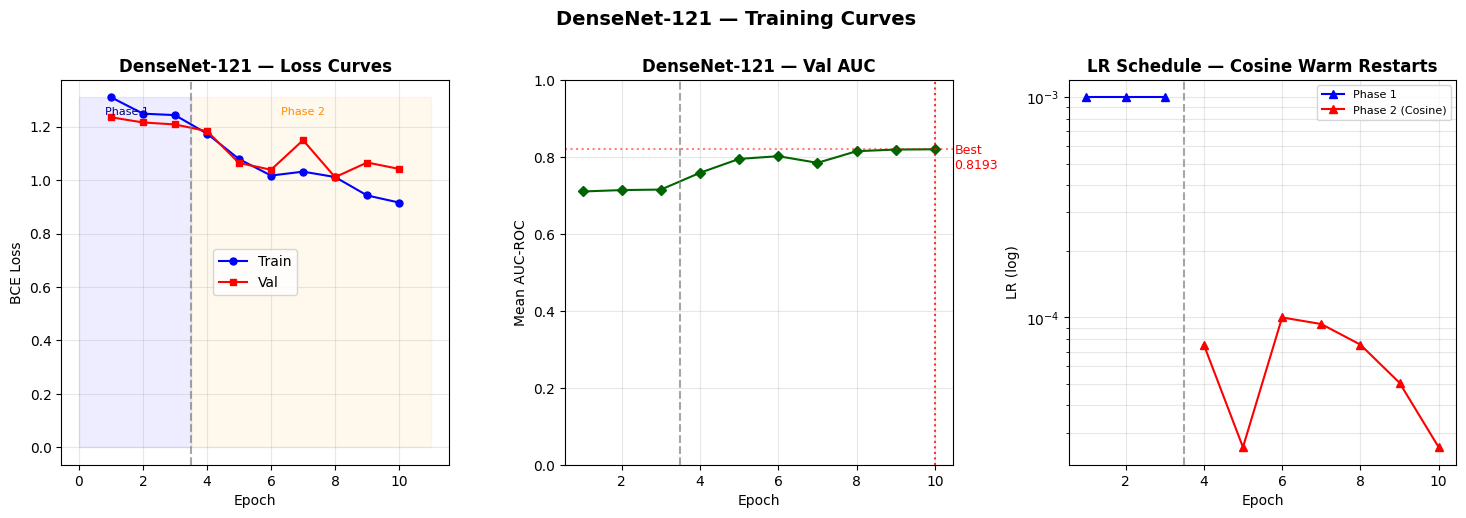

In [9]:
total_ep    = EPOCHS_P1 + EPOCHS_P2
epoch_range = list(range(1, total_ep + 1))

fig = plt.figure(figsize=(18, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.3)

ax1 = fig.add_subplot(gs[0])
ax1.plot(epoch_range, history['train_loss'], 'b-o', ms=5, label='Train')
ax1.plot(epoch_range, history['val_loss'],   'r-s', ms=5, label='Val')
ax1.axvline(x=EPOCHS_P1+0.5, color='gray', linestyle='--', alpha=0.7)
ax1.fill_betweenx([0, max(history['train_loss'])], 0, EPOCHS_P1+0.5, alpha=0.07, color='blue')
ax1.fill_betweenx([0, max(history['train_loss'])], EPOCHS_P1+0.5, total_ep+1, alpha=0.07, color='orange')
ax1.text(1.5, max(history['train_loss'])*0.95, 'Phase 1', ha='center', fontsize=8, color='navy')
ax1.text(EPOCHS_P1+4, max(history['train_loss'])*0.95, 'Phase 2', ha='center', fontsize=8, color='darkorange')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('DenseNet-121 — Loss Curves', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(epoch_range, history['val_auc'], color='darkgreen', marker='D', ms=5)
best_ep = history['val_auc'].index(max(history['val_auc'])) + 1
ax2.axvline(x=best_ep, color='red', linestyle=':', alpha=0.8)
ax2.axhline(y=max(history['val_auc']), color='red', linestyle=':', alpha=0.5)
ax2.axvline(x=EPOCHS_P1+0.5, color='gray', linestyle='--', alpha=0.7)
ax2.annotate(f"Best\n{max(history['val_auc']):.4f}", xy=(best_ep, max(history['val_auc'])),
             xytext=(best_ep+0.5, max(history['val_auc'])-0.05), fontsize=9, color='red')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Mean AUC-ROC')
ax2.set_title('DenseNet-121 — Val AUC', fontweight='bold')
ax2.set_ylim(0, 1); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
ax3.semilogy(epoch_range[:EPOCHS_P1], history['lr'][:EPOCHS_P1], 'b-^', ms=6, label='Phase 1')
ax3.semilogy(epoch_range[EPOCHS_P1:], history['lr'][EPOCHS_P1:],  'r-^', ms=6, label='Phase 2 (Cosine)')
ax3.axvline(x=EPOCHS_P1+0.5, color='gray', linestyle='--', alpha=0.7)
ax3.set_xlabel('Epoch'); ax3.set_ylabel('LR (log)')
ax3.set_title('LR Schedule — Cosine Warm Restarts', fontweight='bold')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3, which='both')

fig.suptitle('DenseNet-121 — Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('densenet121_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Test Evaluation

In [10]:
print("Evaluating on test set...")
test_auc_dense, per_class_auc_dense, all_labels, all_probs = compute_auc(
    model_dense, test_loader, DEVICE, DISEASE_COLS)

sorted_auc = sorted(per_class_auc_dense.items(), key=lambda x: -x[1])

print(f"\n{'='*52}")
print(f"  {'Disease':<25} {'AUC':>8}")
print(f"  {'-'*38}")
for disease, auc in sorted_auc:
    flag = '✓' if auc >= 0.75 else ('~' if auc >= 0.65 else '✗')
    print(f"  {disease:<25} {auc:>7.4f}  {flag}  {'█'*int(auc*20)}")
print(f"  {'-'*38}")
print(f"  {'MEAN AUC':<25} {test_auc_dense:>7.4f}")
print(f"{'='*52}")

Evaluating on test set...

  Disease                        AUC
  --------------------------------------
  Hernia                     0.9218  ✓  ██████████████████
  Emphysema                  0.8948  ✓  █████████████████
  Cardiomegaly               0.8715  ✓  █████████████████
  Pneumothorax               0.8513  ✓  █████████████████
  Edema                      0.8369  ✓  ████████████████
  Effusion                   0.8055  ✓  ████████████████
  Fibrosis                   0.7976  ✓  ███████████████
  Mass                       0.7810  ✓  ███████████████
  Pleural_Thickening         0.7535  ✓  ███████████████
  Atelectasis                0.7389  ~  ██████████████
  Consolidation              0.7245  ~  ██████████████
  Nodule                     0.7200  ~  ██████████████
  Pneumonia                  0.7118  ~  ██████████████
  Infiltration               0.7049  ~  ██████████████
  --------------------------------------
  MEAN AUC                   0.7939


## 10. Visualizations

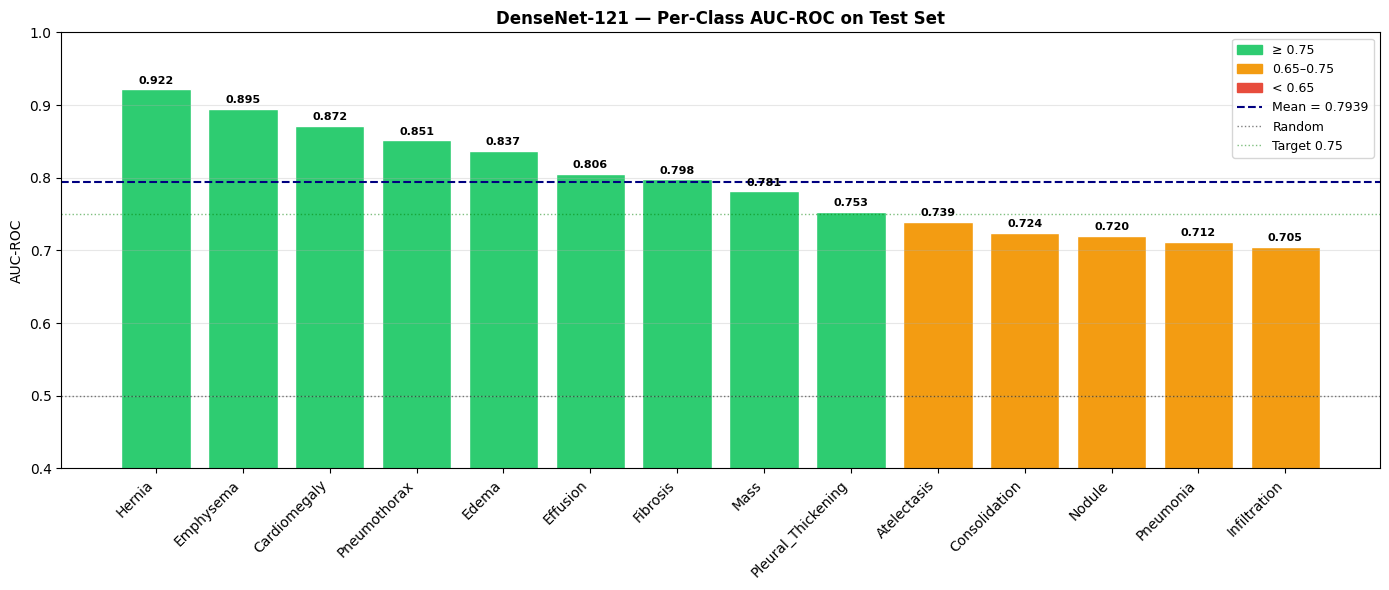

In [11]:
# Per-class AUC bar chart
diseases = [d for d, _ in sorted_auc]
aucs     = [a for _, a in sorted_auc]
colors   = ['#2ecc71' if a >= 0.75 else ('#f39c12' if a >= 0.65 else '#e74c3c') for a in aucs]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(diseases, aucs, color=colors, edgecolor='white')
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(y=test_auc_dense, color='navy', linestyle='--', lw=1.5, label=f'Mean = {test_auc_dense:.4f}')
ax.axhline(y=0.5,  color='black', linestyle=':', lw=1, alpha=0.5, label='Random')
ax.axhline(y=0.75, color='green', linestyle=':', lw=1, alpha=0.5, label='Target 0.75')
patches = [mpatches.Patch(color='#2ecc71', label='≥ 0.75'),
           mpatches.Patch(color='#f39c12', label='0.65–0.75'),
           mpatches.Patch(color='#e74c3c', label='< 0.65')]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0][:3], fontsize=9)
ax.set_ylim(0.4, 1.0); ax.set_ylabel('AUC-ROC')
ax.set_title('DenseNet-121 — Per-Class AUC-ROC on Test Set', fontweight='bold')
ax.set_xticklabels(diseases, rotation=45, ha='right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('densenet121_per_class_auc.png', dpi=150, bbox_inches='tight')
plt.show()

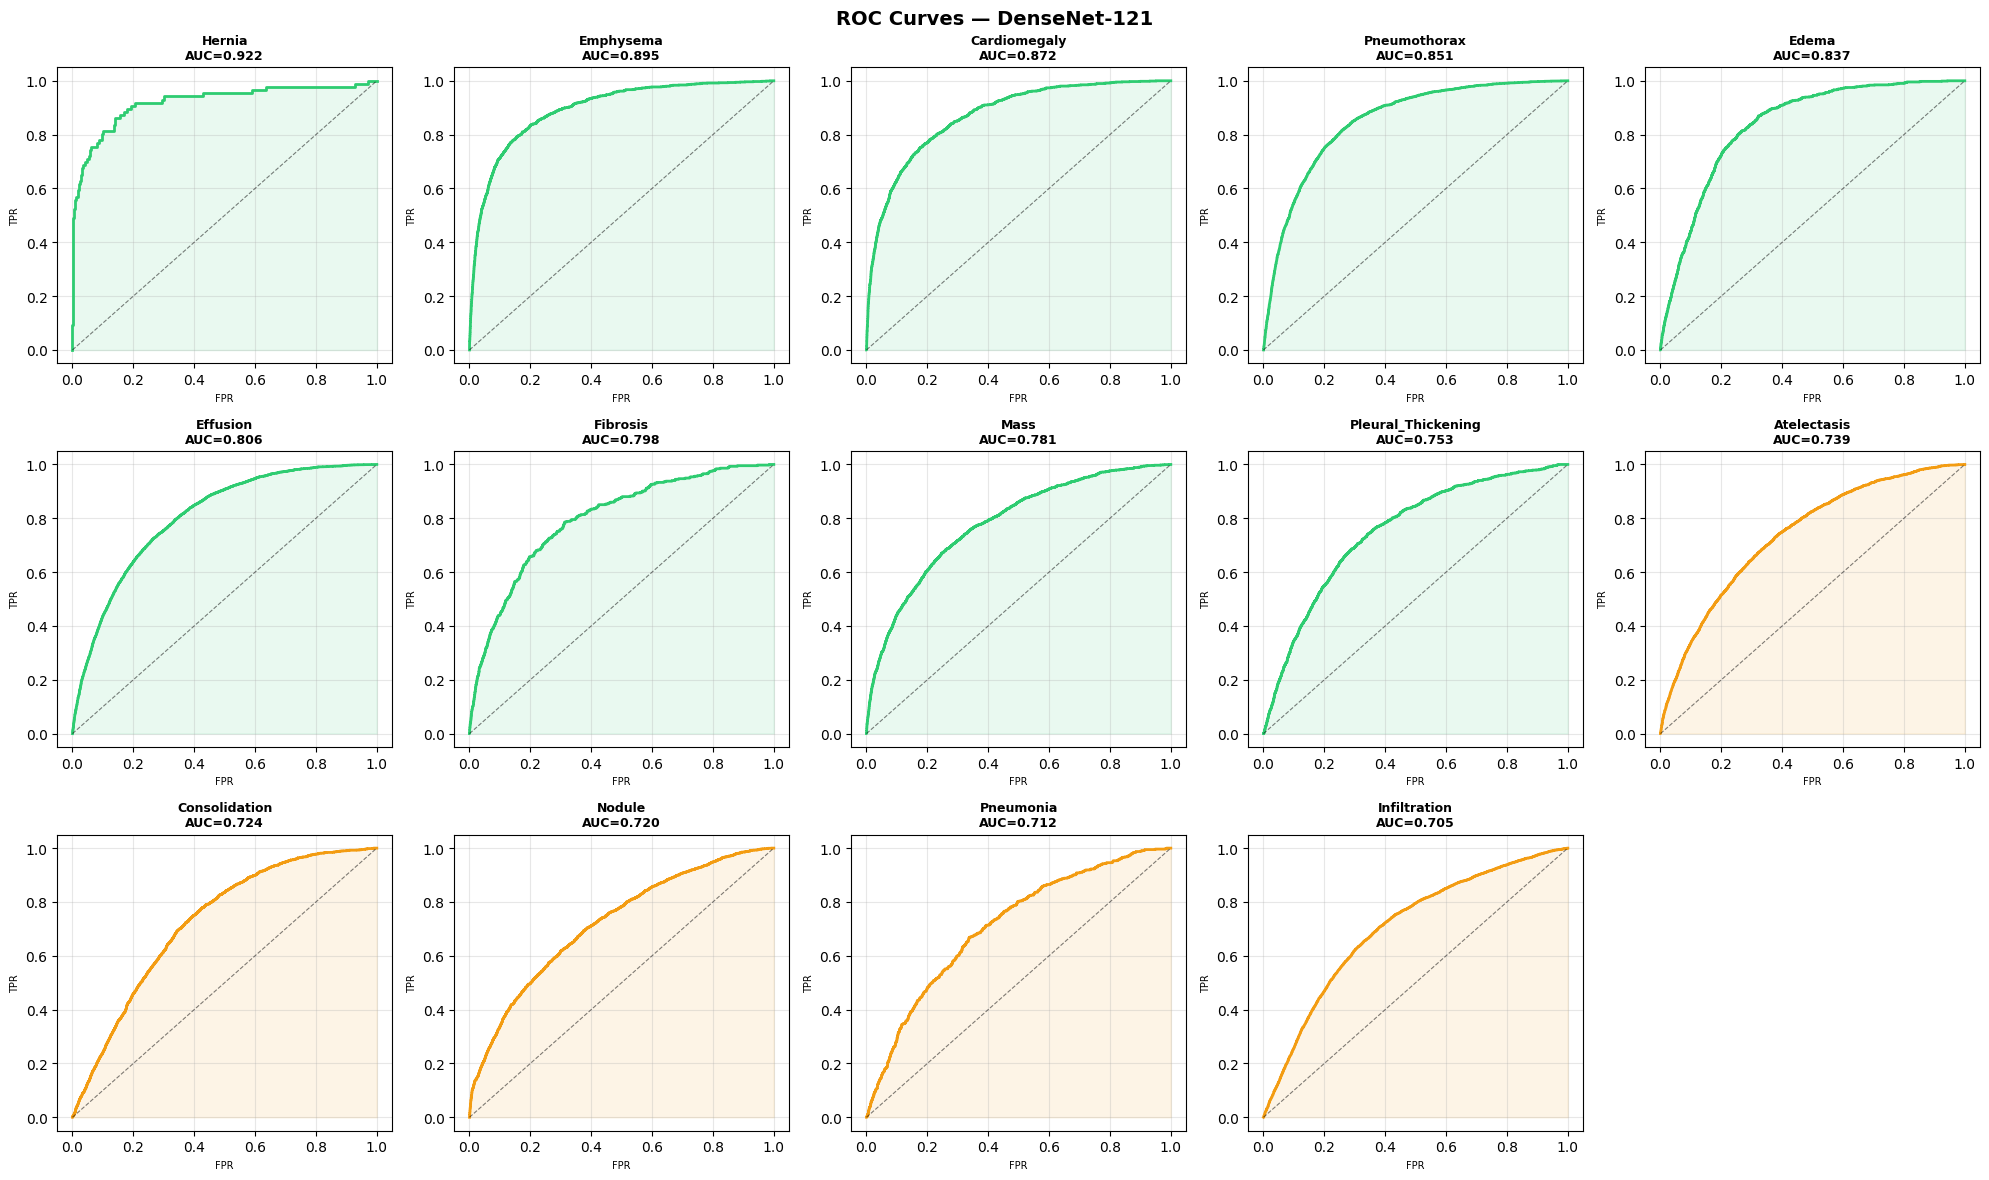

In [12]:
# ROC curves — all 14 diseases
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('ROC Curves — DenseNet-121', fontsize=14, fontweight='bold')

for ax, (disease, auc_score) in zip(axes.flat, sorted_auc):
    i = DISEASE_COLS.index(disease)
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    color = '#2ecc71' if auc_score >= 0.75 else ('#f39c12' if auc_score >= 0.65 else '#e74c3c')
    ax.plot(fpr, tpr, color=color, lw=2)
    ax.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)
    ax.set_title(f'{disease}\nAUC={auc_score:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=7); ax.set_ylabel('TPR', fontsize=7); ax.grid(alpha=0.3)

for ax in axes.flat[len(sorted_auc):]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('densenet121_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Grad-CAM — Visual Explanations
Shows which region of the X-ray the model focused on for each disease prediction.

In [20]:
try:
    del grad_cam
except:
    pass

class GradCAM:
    def __init__(self, model, layer='features.denseblock4'):
        self.model = model
        self.layer = layer

    def generate(self, img_tensor, class_idx):
        base = self.model.module if isinstance(self.model, nn.DataParallel) else self.model
        target = dict(base.named_modules())[self.layer]

        activations = {}
        fh = target.register_forward_hook(lambda m, i, o: activations.update({'v': o}))

        try:
            self.model.eval()
            inp = img_tensor.unsqueeze(0).to(DEVICE)
            out = self.model(inp)
            score = out[0, class_idx]
            grads = torch.autograd.grad(score, activations['v'])[0]
        finally:
            fh.remove()

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * activations['v'].detach()).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, (224, 224), mode='bilinear', align_corners=False).squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam

grad_cam = GradCAM(model_dense)
print("✓ Grad-CAM initialised")

✓ Grad-CAM initialised


## 12. ResNet50 vs DenseNet-121 Comparison

✓ ResNet50 results loaded


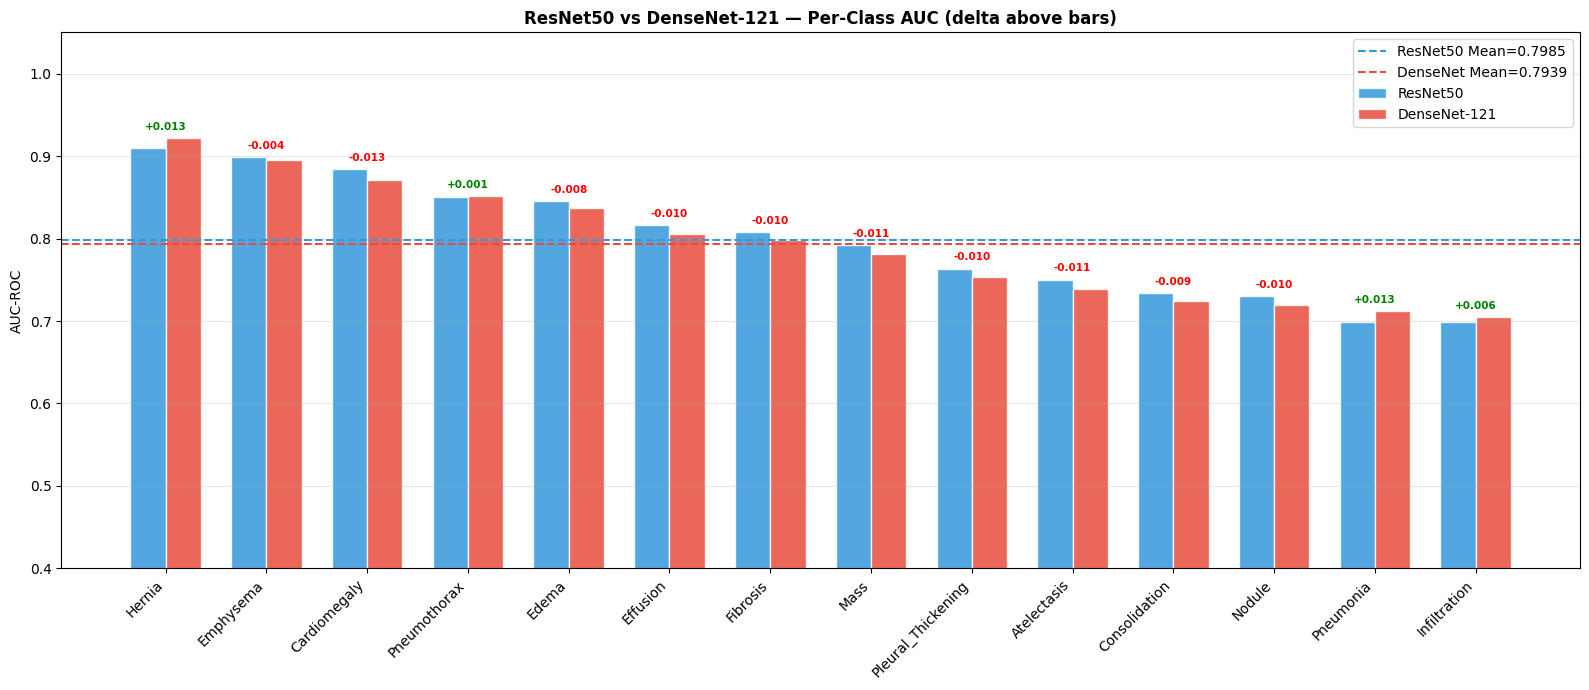

ResNet50 Mean AUC    : 0.7985
DenseNet-121 Mean AUC: 0.7939
Improvement          : -0.0047


In [24]:
# ResNet50 results — from the completed ResNet50 run
resnet_auc_dict = {
    'Hernia'             : 0.9092,
    'Emphysema'          : 0.8989,
    'Cardiomegaly'       : 0.8843,
    'Pneumothorax'       : 0.8504,
    'Edema'              : 0.8453,
    'Effusion'           : 0.8159,
    'Fibrosis'           : 0.8076,
    'Mass'               : 0.7921,
    'Pleural_Thickening' : 0.7635,
    'Atelectasis'        : 0.7502,
    'Consolidation'      : 0.7338,
    'Nodule'             : 0.7300,
    'Infiltration'       : 0.6992,
    'Pneumonia'          : 0.6988,
}
print("✓ ResNet50 results loaded")

diseases_sorted = [d for d, _ in sorted(per_class_auc_dense.items(), key=lambda x: -x[1])]
dense_aucs  = [per_class_auc_dense[d] for d in diseases_sorted]
resnet_aucs = [resnet_auc_dict.get(d, 0.0) for d in diseases_sorted]
mean_resnet = np.mean(resnet_aucs)
mean_dense  = np.mean(dense_aucs)

x, width = np.arange(len(diseases_sorted)), 0.35
fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - width/2, resnet_aucs, width, label='ResNet50',     color='#3498db', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, dense_aucs,  width, label='DenseNet-121', color='#e74c3c', alpha=0.85, edgecolor='white')

for i, (r, d) in enumerate(zip(resnet_aucs, dense_aucs)):
    diff = d - r
    ax.text(i, max(r,d)+0.01, f'{diff:+.3f}', ha='center', fontsize=7.5,
            color='green' if diff > 0 else 'red', fontweight='bold')

ax.axhline(y=mean_resnet, color='#3498db', linestyle='--', lw=1.5, label=f'ResNet50 Mean={mean_resnet:.4f}')
ax.axhline(y=mean_dense,  color='#e74c3c', linestyle='--', lw=1.5, label=f'DenseNet Mean={mean_dense:.4f}')
ax.set_xticks(x); ax.set_xticklabels(diseases_sorted, rotation=45, ha='right')
ax.set_ylim(0.4, 1.05); ax.set_ylabel('AUC-ROC')
ax.set_title('ResNet50 vs DenseNet-121 — Per-Class AUC (delta above bars)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ResNet50 Mean AUC    : {mean_resnet:.4f}")
print(f"DenseNet-121 Mean AUC: {mean_dense:.4f}")
print(f"Improvement          : {mean_dense - mean_resnet:+.4f}")

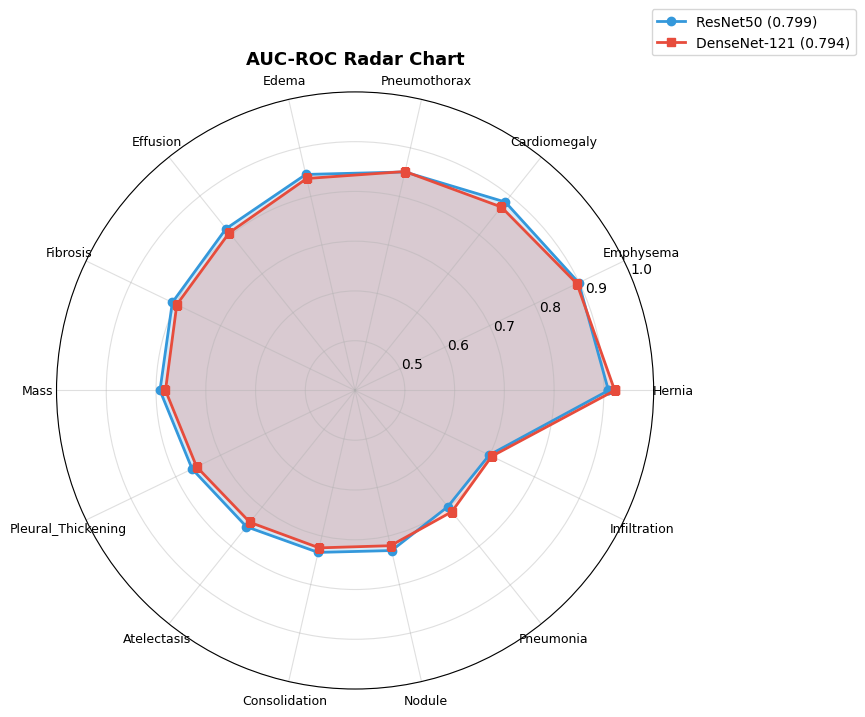

In [25]:
# Radar chart
labels  = diseases_sorted
N       = len(labels)
angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
rv = resnet_aucs + resnet_aucs[:1]
dv = dense_aucs  + dense_aucs[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
ax.fill(angles, rv, alpha=0.2, color='#3498db')
ax.plot(angles, rv, 'o-', color='#3498db', lw=2, label=f'ResNet50 ({mean_resnet:.3f})')
ax.fill(angles, dv, alpha=0.2, color='#e74c3c')
ax.plot(angles, dv, 's-', color='#e74c3c', lw=2, label=f'DenseNet-121 ({mean_dense:.3f})')
ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
ax.set_ylim(0.4, 1.0); ax.set_yticks([0.5,0.6,0.7,0.8,0.9,1.0])
ax.set_title('AUC-ROC Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Save Results

In [26]:
summary_df = pd.DataFrame({
    'Disease'        : DISEASE_COLS,
    'Train_Pos'      : df_train[DISEASE_COLS].sum().values,
    'Prevalence_%'   : (df_train[DISEASE_COLS].mean() * 100).round(2).values,
    'ResNet50_AUC'   : [round(resnet_auc_dict.get(d, 0.0), 4) for d in DISEASE_COLS],
    'DenseNet121_AUC': [round(per_class_auc_dense[d], 4) for d in DISEASE_COLS],
    'Delta'          : [round(per_class_auc_dense[d] - resnet_auc_dict.get(d, 0.0), 4) for d in DISEASE_COLS],
}).sort_values('DenseNet121_AUC', ascending=False).reset_index(drop=True)

print(summary_df.to_string(index=False))
print(f"\nResNet50 Mean AUC    : {mean_resnet:.4f}")
print(f"DenseNet-121 Mean AUC: {mean_dense:.4f}")
print(f"Δ Improvement        : {mean_dense - mean_resnet:+.4f}")

summary_df.to_csv('densenet121_results.csv', index=False)
summary_df.to_csv('final_model_comparison.csv', index=False)
print("\nSaved: densenet121_results.csv + final_model_comparison.csv")

           Disease  Train_Pos  Prevalence_%  ResNet50_AUC  DenseNet121_AUC   Delta
            Hernia        122          0.16        0.9092           0.9218  0.0126
         Emphysema       1317          1.69        0.8989           0.8948 -0.0041
      Cardiomegaly       1549          1.99        0.8843           0.8715 -0.0128
      Pneumothorax       2394          3.07        0.8504           0.8513  0.0009
             Edema       1253          1.61        0.8453           0.8369 -0.0084
          Effusion       7852         10.07        0.8159           0.8055 -0.0104
          Fibrosis       1111          1.42        0.8076           0.7976 -0.0100
              Mass       3646          4.68        0.7921           0.7810 -0.0111
Pleural_Thickening       1997          2.56        0.7635           0.7535 -0.0100
       Atelectasis       7405          9.50        0.7502           0.7389 -0.0113
     Consolidation       2584          3.31        0.7338           0.7245 -0.0093
    